In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

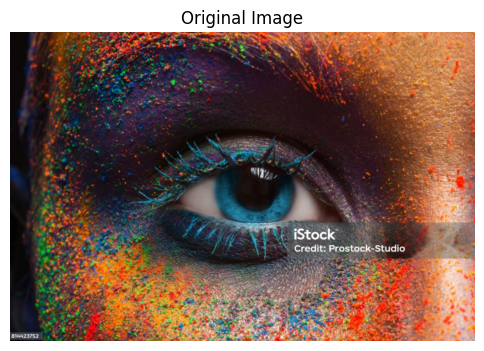

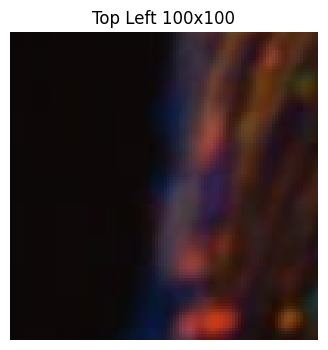

In [2]:
# Load image
img = Image.open('/content/drive/MyDrive/AI ML/Data/eye.png')
img_array = np.array(img)

# Display original image
plt.figure(figsize=(6, 6))
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

# 1) Top-left 100x100 pixels
top_left = img_array[:100, :100]

plt.figure(figsize=(4, 4))
plt.imshow(top_left)
plt.title("Top Left 100x100")
plt.axis("off")
plt.show()


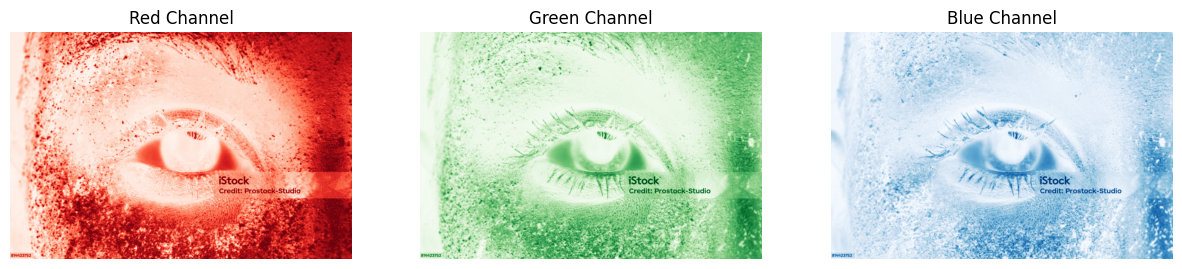

In [3]:
# 2) Separate R, G, B channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(R, cmap="Reds")
axes[0].set_title("Red Channel")
axes[0].axis("off")

axes[1].imshow(G, cmap="Greens")
axes[1].set_title("Green Channel")
axes[1].axis("off")

axes[2].imshow(B, cmap="Blues")
axes[2].set_title("Blue Channel")
axes[2].axis("off")

plt.show()

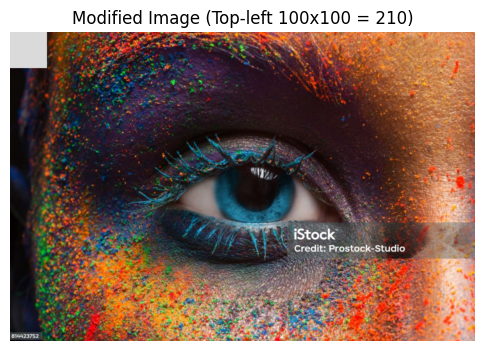

In [4]:
# 3) Modify top-left 100x100 pixels to value 210
modified_img = img_array.copy()
modified_img[:100, :100] = 210

plt.figure(figsize=(6, 6))
plt.imshow(modified_img)
plt.title("Modified Image (Top-left 100x100 = 210)")
plt.axis("off")
plt.show()

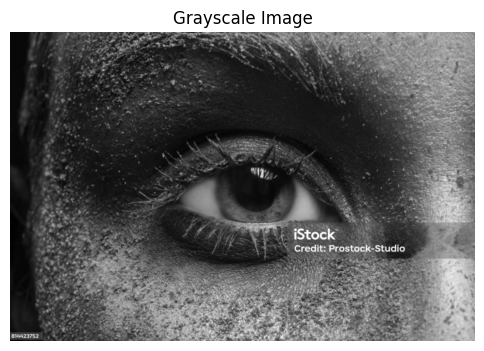

In [5]:
# Load grayscale image
gray_img = Image.open("/content/drive/MyDrive/AI ML/Data/eye.png").convert("L")
gray_array = np.array(gray_img)

# 1) Display grayscale image
plt.figure(figsize=(6, 6))
plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

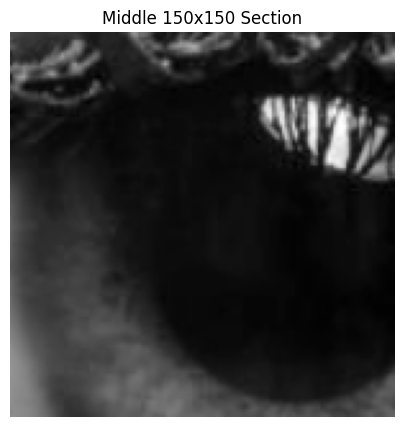

In [6]:
# 2) Extract middle 150x150 section
h, w = gray_array.shape
start_h = h // 2 - 75
end_h = h // 2 + 75
start_w = w // 2 - 75
end_w = w // 2 + 75

middle_section = gray_array[start_h:end_h, start_w:end_w]

plt.figure(figsize=(5, 5))
plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

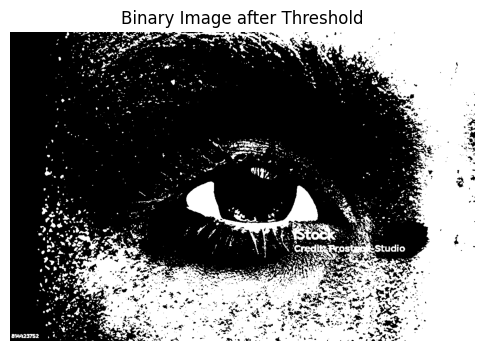

In [7]:
# 3) Apply threshold
binary_img = np.where(gray_array < 100, 0, 255)

plt.figure(figsize=(6, 6))
plt.imshow(binary_img, cmap="gray")
plt.title("Binary Image after Threshold")
plt.axis("off")
plt.show()

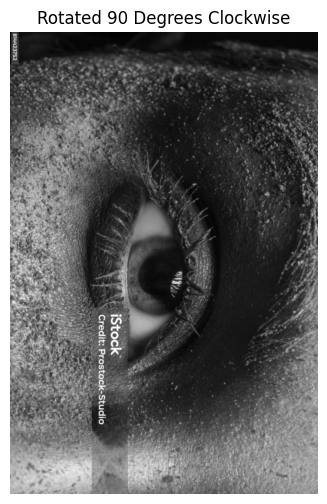

In [8]:
# 4) Rotate 90 degrees clockwise
rotated_img = gray_img.transpose(Image.Transpose.ROTATE_270)

plt.figure(figsize=(6, 6))
plt.imshow(rotated_img, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

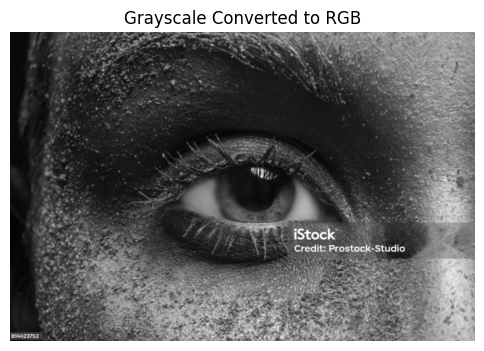

In [9]:
# 5) Convert grayscale to RGB
rgb_img = np.stack([gray_array, gray_array, gray_array], axis=-1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_img)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

Image Compression and Decompression using PCA.

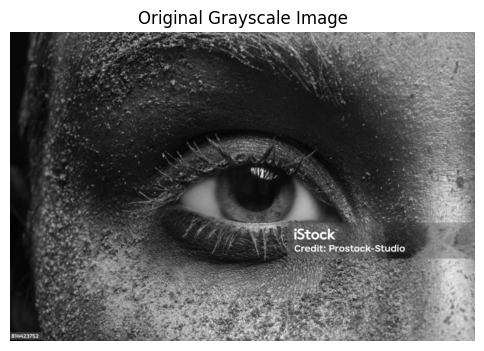

Image shape: (836, 1258)


In [10]:
# Load image and convert to grayscale
img = Image.open("/content/drive/MyDrive/AI ML/Data/eye.png").convert("L")
img_array = np.array(img, dtype=np.float64)

plt.figure(figsize=(6, 6))
plt.imshow(img_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()
print("Image shape:", img_array.shape)

In [19]:
# Standardize / center data
mean_vec = np.mean(img_array, axis=0)
centered_data = img_array - mean_vec

In [20]:
# Covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

print("Covariance matrix shape:", cov_matrix.shape)

Covariance matrix shape: (1258, 1258)


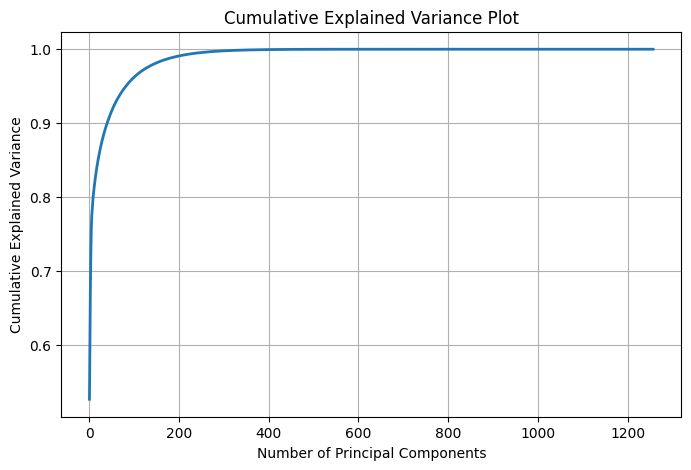

In [28]:
# 2. Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, linewidth=2)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid(True)
plt.show()

Choose principal components using explained variance

In [22]:
# Find k values for different explained variance targets
targets = [0.70, 0.85, 0.95, 0.99]
k_values = []

for t in targets:
    k = np.argmax(cumulative_variance >= t) + 1
    k_values.append(k)
    print(f"{int(t*100)}% explained variance -> k = {k}")

70% explained variance -> k = 4
85% explained variance -> k = 21
95% explained variance -> k = 83
99% explained variance -> k = 194


Reconstruction function

In [23]:
def reconstruct_image(centered_data, eigenvectors, mean_vec, k):
    top_k_vectors = eigenvectors[:, :k]
    projected_data = np.dot(centered_data, top_k_vectors)
    reconstructed_data = np.dot(projected_data, top_k_vectors.T) + mean_vec
    return reconstructed_data

Reconstruct using four different principal component combinations

In [24]:
reconstructed_images = []

for k in k_values:
    reconstructed = reconstruct_image(centered_data, eigenvectors, mean_vec, k)
    reconstructed_images.append((k, reconstructed))

Display results

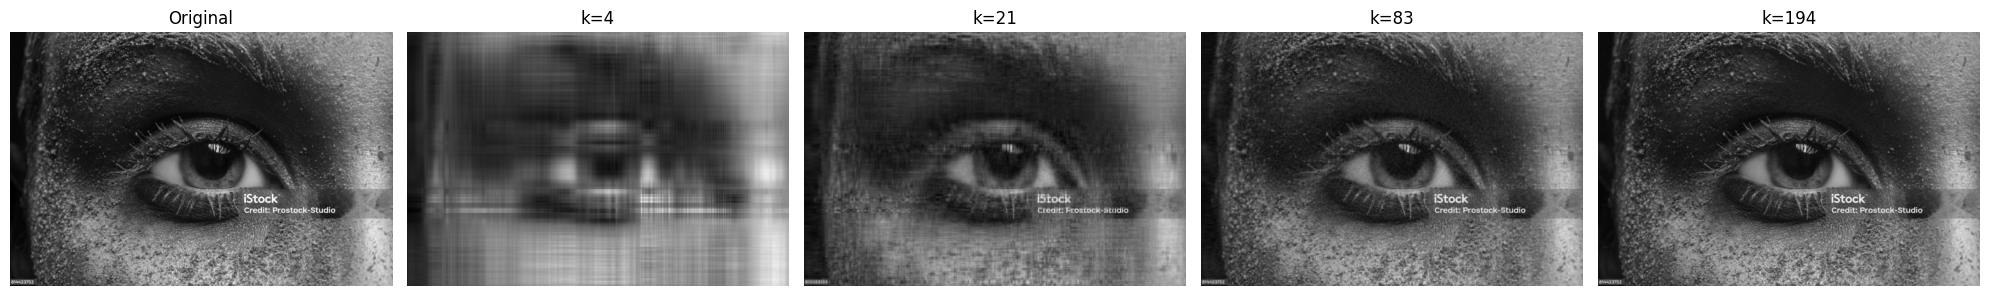

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Original image
axes[0].imshow(img_array, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

# Reconstructed images
for i, (k, rec_img) in enumerate(reconstructed_images):
    axes[i+1].imshow(rec_img, cmap="gray")
    axes[i+1].set_title(f"k={k}")
    axes[i+1].axis("off")

plt.tight_layout()
plt.show()

Evaluate reconstruction error

In [26]:
print("Reconstruction Errors:\n")

for k, rec_img in reconstructed_images:
    mse = np.mean((img_array - rec_img) ** 2)
    print(f"k = {k}, MSE = {mse:.4f}")

Reconstruction Errors:

k = 4, MSE = 496.6357
k = 21, MSE = 260.1979
k = 83, MSE = 87.3609
k = 194, MSE = 17.6447
